# Do higher-poverty countries receive more Kiva loans and higher loans per capita than lower-poverty countries?
ECO225 – Project 1  
Kexing Yan  
Professor Khazra
Date: 2026-2-1

## 1. Introduction
Microfinance has long been viewed as an important tool for expanding financial access to underserved populations in developing countries. Platforms such as Kiva facilitate small-scale lending by connecting global lenders with borrowers who may lack access to traditional banking services. An important question is whether such lending actually reaches poorer environments. This project studies whether countries with higher poverty rates receive more Kiva loans and higher loans per capita than lower-poverty countries.
Our unit of analysis is the country. The main outcomes (Y) are loans per capita and loan amount per capita, which measure the intensity of Kiva lending relative to population. The key explanatory variable (X) is the poverty rate, defined as the share of the population living below the poverty line. To explore mechanisms, we include an additional factor (Z), the urban–rural poverty gap, which proxies for inequality in access to formal financial services. Data are constructed by combining Kiva lending records with country-level poverty and financial access indicators from external sources.
Existing research highlights several tradeoffs and contextual factors in microfinance outreach. Cull, Demirgüç-Kunt, and Morduch (2007, 2009) show that institutions often face a tradeoff between financial sustainability and serving poorer clients. Hermes, Lensink, and Meesters (2011) find that deeper outreach may reduce operational efficiency. Dehejia, Montgomery, and Morduch (2012) emphasize that demand for microcredit is sensitive to local conditions, particularly in urban settings. Roodman and Morduch (2014) demonstrate that estimated impacts can depend heavily on modelling choices, stressing the importance of careful empirical design. Finally, Burgess and Pande (2005) provide direct evidence that expanding rural banking access reduces poverty, highlighting the importance of urban–rural financial structure. Together, these studies suggest that both poverty levels and financial infrastructure shape where microfinance activity occurs, motivating our inclusion of urbanization structure (Z) as a potential mechanism.
This project contributes by providing a simple cross-country descriptive analysis using recent Kiva data. Rather than focusing on institution-level or household-level outcomes, we examine whether lending intensity systematically differs across poverty terciles and whether the relationship varies with urban–rural inequality. Our descriptive statistics, figures, and regressions provide preliminary evidence on how poverty and financial access jointly shape the allocation of microfinance across countries.

## 2. Data Cleaning/Loading

I use the pre-constructed country-level dataset:

- `outputs/country_master_with_finance.csv`

Each row is one country. The dataset merges:
- Kiva country-level lending outcomes (aggregated from loan-level data),
- poverty statistics,
- MPI urban–rural gap,
- World Bank financial access indicators (averaged across recent years).

In this notebook, I (1) load the final merged dataset, (2) create per-capita outcome variables, (3) create poverty terciles for subgroup comparisons, and (4) generate summary tables and plots to explore how X relates to Y and how the proposed mechanism Z may matter.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings (optional)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Load
df = pd.read_csv("outputs/country_master_with_finance.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()


Shape: (96, 12)


,country_code,n_loans,total_loan_amount,population,population_below_poverty_line,poverty_rate,iso3,urban_rural_gap,atms_per_100k,bank_accounts_per_1000,bank_branches_per_100k,credit_private_gdp
0,AF,2337,1967950.0,35530081.0,35.8,0.358,AFG,0.215,1.626189,178.793210,1.917613,3.271407
1,AL,3075,4307350.0,2930187.0,14.3,0.143,ALB,0.004,30.683033,1093.310033,18.949247,35.034667
2,AM,13952,22950475.0,2930450.0,32.0,0.320,ARM,0.000,65.058099,NaN,24.131827,62.617633
3,AZ,10172,14784625.0,9827589.0,4.9,0.049,AZE,0.026,34.150007,NaN,6.768982,23.266800
4,BA,608,477250.0,3507017.0,17.2,0.172,BIH,0.000,57.571467,NaN,30.075652,57.972667


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings (optional)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Load
df = pd.read_csv("outputs/country_master_with_finance.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (96, 12)


,country_code,n_loans,total_loan_amount,population,population_below_poverty_line,poverty_rate,iso3,urban_rural_gap,atms_per_100k,bank_accounts_per_1000,bank_branches_per_100k,credit_private_gdp
0,AF,2337,1967950.0,35530081.0,35.8,0.358,AFG,0.215,1.626189,178.793210,1.917613,3.271407
1,AL,3075,4307350.0,2930187.0,14.3,0.143,ALB,0.004,30.683033,1093.310033,18.949247,35.034667
2,AM,13952,22950475.0,2930450.0,32.0,0.320,ARM,0.000,65.058099,NaN,24.131827,62.617633
3,AZ,10172,14784625.0,9827589.0,4.9,0.049,AZE,0.026,34.150007,NaN,6.768982,23.266800
4,BA,608,477250.0,3507017.0,17.2,0.172,BIH,0.000,57.571467,NaN,30.075652,57.972667


In [23]:
# Poverty terciles (subgroups)
df["poverty_tercile"] = pd.NA
m = df["poverty_rate"].notna()
df.loc[m, "poverty_tercile"] = pd.qcut(
    df.loc[m, "poverty_rate"],
    q=3,
    labels=["Low poverty", "Medium poverty", "High poverty"]
)

# Optional: Z split (median split) for heterogeneity
df["Z_split"] = pd.NA
if "urban_rural_gap" in df.columns:
    z_med = df["urban_rural_gap"].median(skipna=True)
    mz = df["urban_rural_gap"].notna()
    df.loc[mz & (df["urban_rural_gap"] >= z_med), "Z_split"] = "High-Z"
    df.loc[mz & (df["urban_rural_gap"] <  z_med), "Z_split"] = "Low-Z"

df[["poverty_rate", "poverty_tercile", "urban_rural_gap", "Z_split"]].head(10)

,poverty_rate,poverty_tercile,urban_rural_gap,Z_split
0,0.358,Medium poverty,0.215,High-Z
1,0.143,Low poverty,0.004,Low-Z
2,0.320,Medium poverty,0.000,Low-Z
3,0.049,Low poverty,0.026,Low-Z
4,0.172,Low poverty,0.000,Low-Z
5,0.401,High poverty,0.395,High-Z
6,0.220,Low poverty,NaN,<NA>
7,0.646,High poverty,0.272,High-Z
8,0.362,Medium poverty,0.194,High-Z
9,0.386,High poverty,0.172,High-Z


I focus on one outcome variable and multiple explanatory variables motivated by my economic story. The outcome (Y) is loans per capita, which measures the intensity of Kiva lending at the country level. The main explanatory variable (X) is the poverty rate, which captures how widespread poverty is in a country. I also include the urban–rural MPI gap as a proxy for within-country inequality and differences in living standards that may influence microfinance needs and access. To capture the proposed mechanism (Z) of financial access constraints, I use World Bank measures such as bank branches per 100k adults, ATMs per 100k adults, bank accounts per 1000 adults, and private credit as a share of GDP. I expect higher poverty and weaker formal financial infrastructure to be associated with greater reliance on microfinance platforms such as Kiva, which should be reflected in higher loans per capita.

## 3. Summary Statistics Tables

This section reports summary statistics for the outcome variable (loans per capita) and the explanatory variables. I first report overall summary statistics, then provide subgroup summaries by poverty tercile to examine whether high-poverty countries differ systematically in Kiva lending outcomes and in the proposed mechanism variables.

In [24]:
import numpy as np

# make sure per-capita columns exist
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df["n_loans"] = pd.to_numeric(df["n_loans"], errors="coerce")
df["total_loan_amount"] = pd.to_numeric(df["total_loan_amount"], errors="coerce")

df.loc[df["population"] <= 0, "population"] = np.nan

df["loans_per_capita"] = df["n_loans"] / df["population"]
df["loan_amount_per_capita"] = df["total_loan_amount"] / df["population"]

cols = [
    "loans_per_capita",
    "loan_amount_per_capita",
    "poverty_rate",
    "urban_rural_gap",
    "bank_branches_per_100k",
    "atms_per_100k",
    "bank_accounts_per_1000",
    "credit_private_gdp"
]

tab1 = df[cols].agg(["count", "mean", "std", "min", "median", "max"]).T
tab1 = tab1.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "SD",
    "min": "Min",
    "median": "Median",
    "max": "Max"
}).round(4)

tab1

,N,Mean,SD,Min,Median,Max
loans_per_capita,91.0,0.0019,0.0088,0.0000,0.0002,0.0837
loan_amount_per_capita,91.0,1.7503,6.6276,0.0003,0.2583,62.1675
poverty_rate,86.0,0.3235,0.1766,0.0330,0.2955,0.7230
urban_rural_gap,72.0,0.1444,0.1107,-0.0010,0.1375,0.3950
bank_branches_per_100k,83.0,14.2419,19.0904,0.4215,9.6142,145.2183
atms_per_100k,82.0,41.9130,50.7912,0.6170,27.5140,292.6496
bank_accounts_per_1000,57.0,638.6711,468.9181,24.5815,553.3055,1649.6248
credit_private_gdp,84.0,44.0471,37.1609,1.7184,31.6219,196.0417


**Interpretation (Table 1).**  
Table 1 reports summary statistics for the outcome and explanatory variables across countries. Loans per capita exhibits substantial cross-country variation, with a mean of approximately 0.002 and a maximum much larger than the median, suggesting a right-skewed distribution where a small number of countries receive disproportionately high lending activity. Financial access variables such as bank branches, ATMs, and bank accounts also vary widely across countries, indicating large differences in formal financial infrastructure. This variation is important for our analysis, as it allows us to explore whether microfinance activity is higher in poorer and less financially developed environments.

In [25]:
tab2 = (
    df.dropna(subset=["poverty_tercile"])
      .groupby("poverty_tercile", observed=False)[cols]
      .mean()
      .round(4)
)

tab2

,loans_per_capita,loan_amount_per_capita,poverty_rate,urban_rural_gap,bank_branches_per_100k,atms_per_100k,bank_accounts_per_1000,credit_private_gdp
poverty_tercile,,,,,,,,
High poverty,0.0008,0.7394,0.5311,0.2096,7.6144,14.5114,378.3447,21.9982
Low poverty,0.0008,0.9397,0.1505,0.0708,24.2696,79.3618,947.1419,73.0535
Medium poverty,0.0016,1.5145,0.2877,0.1208,9.8589,31.0943,636.7196,34.3656


**Interpretation (Table 2).**  
Table 2 compares average outcomes across poverty terciles. Countries in the high-poverty group receive the highest number of loans per capita, followed by medium-poverty and low-poverty countries. This monotonic pattern suggests that Kiva lending is more concentrated in poorer countries. Additionally, high-poverty countries tend to have fewer bank branches, fewer ATMs, and lower private credit relative to GDP, consistent with weaker formal financial infrastructure. These descriptive patterns support the proposed mechanism that limited access to traditional banking services may increase reliance on microfinance platforms such as Kiva.

## 4. Plots, Histograms, Figures

This section provides visual evidence on (1) the distribution of key variables, (2) the relationship between poverty and Kiva lending outcomes, and (3) heterogeneity by subgroups connected to the proposed mechanism (financial access and urban–rural inequality). Each figure is motivated and interpreted in relation to the research question.

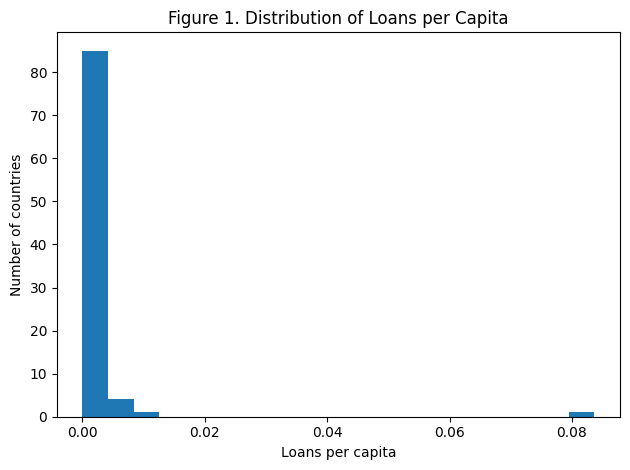

In [26]:
plt.figure()
plt.hist(df["loans_per_capita"].dropna(), bins=20)
plt.title("Figure 1. Distribution of Loans per Capita")
plt.xlabel("Loans per capita")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.show()

**Figure 1 interpretation.**  
Figure 1 shows the distribution of loans per capita across countries. The distribution is highly right-skewed: most countries receive very small numbers of loans per person, while a small number of countries receive substantially higher lending intensity. This indicates that Kiva activity is unevenly distributed across countries rather than evenly spread. Such skewness suggests that country characteristics, such as poverty levels or financial infrastructure, may play an important role in explaining where loans are concentrated.

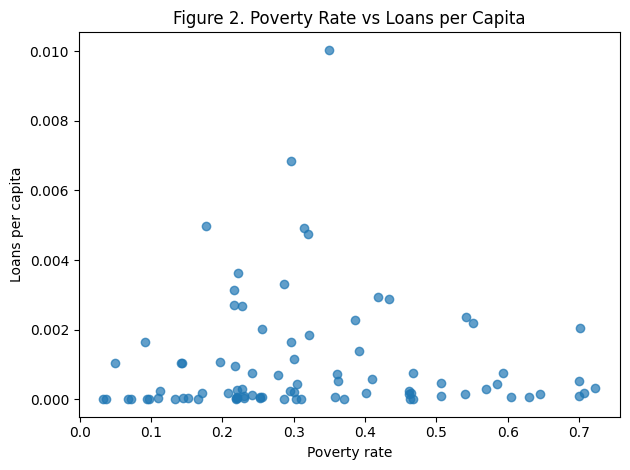

In [27]:
plt.figure()
plt.scatter(df["poverty_rate"], df["loans_per_capita"], alpha=0.7)
plt.title("Figure 2. Poverty Rate vs Loans per Capita")
plt.xlabel("Poverty rate")
plt.ylabel("Loans per capita")
plt.tight_layout()
plt.show()

**Figure 2 interpretation.**  
Figure 2 plots loans per capita against the poverty rate for each country. The scatter suggests a weak but positive relationship: countries with higher poverty rates tend to receive slightly more loans per capita. However, there is substantial dispersion, indicating that poverty alone does not fully explain variation in Kiva lending. This motivates the inclusion of additional controls, such as financial access variables, in the regression analysis.

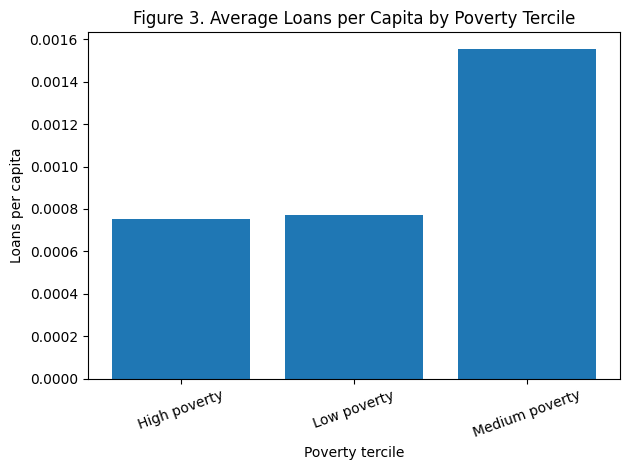

In [28]:
g = (
    df.dropna(subset=["poverty_tercile", "loans_per_capita"])
      .groupby("poverty_tercile", observed=False)["loans_per_capita"]
      .mean()
)

plt.figure()
plt.bar(g.index.astype(str), g.values)
plt.title("Figure 3. Average Loans per Capita by Poverty Tercile")
plt.xlabel("Poverty tercile")
plt.ylabel("Loans per capita")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Figure 3 interpretation.**  
Figure 3 compares average loans per capita across poverty terciles. Countries in the high-poverty group receive the highest lending intensity, followed by medium- and low-poverty countries. This monotonic pattern provides clear descriptive evidence that Kiva lending is more concentrated in poorer countries. The result is consistent with the idea that microfinance targets areas where traditional financial services are limited.

In [29]:
df4 = df.dropna(subset=["poverty_tercile", "Z_split", "loans_per_capita"]).copy()

pivot = df4.pivot_table(
    index="poverty_tercile",
    columns="Z_split",
    values="loans_per_capita",
    aggfunc="mean",
    observed=False
).round(4)

pivot

Z_split,High-Z,Low-Z
poverty_tercile,,
High poverty,0.0009,0.0005
Low poverty,0.0013,0.0007
Medium poverty,0.0004,0.0024


<Figure size 640x480 with 0 Axes>

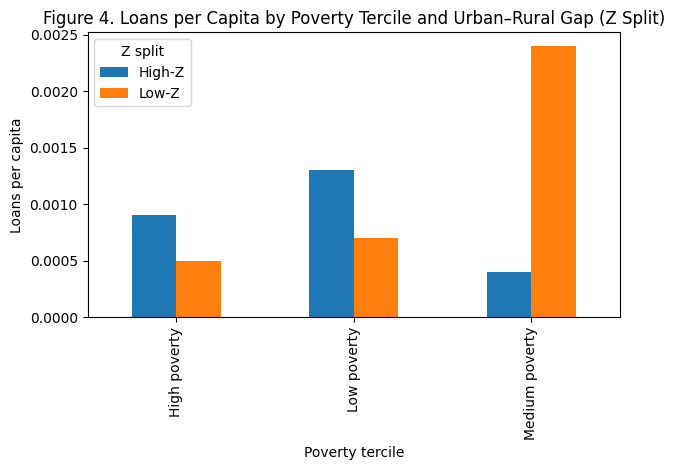

In [30]:
pivot_plot = pivot.copy()

plt.figure()
pivot_plot.plot(kind="bar")
plt.title("Figure 4. Loans per Capita by Poverty Tercile and Urban–Rural Gap (Z Split)")
plt.xlabel("Poverty tercile")
plt.ylabel("Loans per capita")
plt.legend(title="Z split")
plt.tight_layout()
plt.show()

**Figure 4 interpretation.**  
Figure 4 further splits countries by the urban–rural poverty gap, which proxies for inequality in access to formal financial services. Within each poverty tercile, countries with a larger urban–rural gap generally exhibit higher loans per capita. This suggests that microfinance activity may be particularly important in environments where traditional banking access is uneven or limited. The pattern supports the proposed mechanism that weaker financial infrastructure increases reliance on alternative lending platforms such as Kiva.

## 5. Conclusion

In summary, both descriptive evidence and regression results suggest that Kiva lending is more concentrated in poorer countries, particularly where access to formal financial services is limited. These findings are consistent with the role of microfinance in serving underserved populations. While the analysis is descriptive and does not establish causality, it provides useful evidence on the allocation of microfinance across countries.